Stage 1 Coding: load the data, check the initial data, perform preprocessing, train four models, then create a comparison table of the main metrics.

1. Install any libraries that may not be available yet.

In [ ]:
!pip -q install xgboost catboost imbalanced-learn shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


2. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

3. Mount Google Drive and read the dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path dataset
file_path = '/content/drive/MyDrive/onlineShope/Online_Shope.csv'

# Cek apakah file ada
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File tidak ditemukan di: {file_path}")

# Load dataset
df = pd.read_csv(file_path)

print("Dataset berhasil dibaca.")
print("Shape:", df.shape)
df.head()

Dataset berhasil dibaca.
Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Initial Data Check

In [ ]:
print("===== DATASET INFORMATION =====")
print(df.info())

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE ROWS =====")
print("Jumlah duplikat:", df.duplicated().sum())

print("\n===== TARGET DISTRIBUTION =====")
if 'Revenue' not in df.columns:
    raise ValueError("Target column 'Revenue' not found. Please check your dataset column names.")

print(df['Revenue'].value_counts(dropna=False))
print(df['Revenue'].value_counts(normalize=True, dropna=False) * 100)

===== INFO DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 1

5. Clean the Target (Revenue)

In [ ]:
# Ensure the target is numeric (0/1)
# UCI dataset typically has Revenue as boolean True/False
if df['Revenue'].dtype == 'bool':
    df['Revenue'] = df['Revenue'].astype(int)
else:
    # Handle cases where values are strings/objects
    revenue_map = {
        'TRUE': 1, 'True': 1, 'true': 1, 1: 1,
        'FALSE': 0, 'False': 0, 'false': 0, 0: 0
    }
    df['Revenue'] = df['Revenue'].map(revenue_map).fillna(df['Revenue'])
    df['Revenue'] = df['Revenue'].astype(int)

print(df['Revenue'].value_counts())

Revenue
0    10422
1     1908
Name: count, dtype: int64


5. A and B

In [ ]:
print("===== DUPLICATE ROWS ANALYSIS =====")
print("Initial number of rows:", df.shape[0])
print("Number of duplicate rows:", df.duplicated().sum())

# Create a copy of the dataset without duplicate rows
df_dedup = df.drop_duplicates().reset_index(drop=True)

print("\n===== AFTER REMOVING DUPLICATES =====")
print("Number of rows after deduplication:", df_dedup.shape[0])
print("Number of rows removed:", df.shape[0] - df_dedup.shape[0])

print("\n===== TARGET DISTRIBUTION BEFORE DEDUPLICATION =====")
print(df['Revenue'].value_counts())
print(df['Revenue'].value_counts(normalize=True) * 100)

print("\n===== TARGET DISTRIBUTION AFTER DEDUPLICATION =====")
print(df_dedup['Revenue'].value_counts())
print(df_dedup['Revenue'].value_counts(normalize=True) * 100)

===== ANALISIS DUPLICATE ROWS =====
Jumlah baris awal: 12330
Jumlah duplicate rows: 125

===== SETELAH DUPLIKAT DIHAPUS =====
Jumlah baris setelah deduplikasi: 12205
Jumlah baris yang dihapus: 125

===== DISTRIBUSI TARGET SEBELUM DEDUPLIKASI =====
Revenue
0    10422
1     1908
Name: count, dtype: int64
Revenue
0    84.525547
1    15.474453
Name: proportion, dtype: float64

===== DISTRIBUSI TARGET SETELAH DEDUPLIKASI =====
Revenue
0    10297
1     1908
Name: count, dtype: int64
Revenue
0    84.367063
1    15.632937
Name: proportion, dtype: float64


In [ ]:
# 5B. Separate Features and Target for the Deduplicated Dataset

X_dedup = df_dedup.drop(columns=['Revenue'])
y_dedup = df_dedup['Revenue']

print("Number of deduplicated features:", X_dedup.shape[1])
print("Number of deduplicated target samples:", y_dedup.shape[0])

Jumlah fitur deduplicated: 17
Jumlah target deduplicated: 12205


6. Separate Features and Target

In [ ]:
X = df.drop(columns=['Revenue'])
y = df['Revenue']

print("Number of features:", X.shape[1])
print("Number of target samples:", y.shape[0])

Jumlah fitur: 17
Jumlah target: 12330


7. Identify Numerical and Categorical Features

In [ ]:
# 7 Identify numerical and categorical features
# Explicitly defined so coded identifiers are not treated as ordinal numeric features

categorical_features = [
    'Month',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'VisitorType',
    'Weekend'
]

numerical_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

print("Categorical features:", categorical_features)
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:", numerical_features)
print("Number of numerical features:", len(numerical_features))

print("Categorical features:", categorical_features)
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:", numerical_features)
print("Number of numerical features:", len(numerical_features))

Fitur kategorikal: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Jumlah fitur kategorikal: 7

Fitur numerik: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Jumlah fitur numerik: 10
Fitur kategorikal: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Jumlah fitur kategorikal: 7

Fitur numerik: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Jumlah fitur numerik: 10


8. Split Train-Set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nDistribution of y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribution of y_test:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (9864, 17)
Test shape : (2466, 17)

Distribusi y_train:
Revenue
0    84.529603
1    15.470397
Name: proportion, dtype: float64

Distribusi y_test:
Revenue
0    84.509327
1    15.490673
Name: proportion, dtype: float64


In [ ]:
# 8A. Train-Test Split for the Deduplicated Dataset

X_train_dedup, X_test_dedup, y_train_dedup, y_test_dedup = train_test_split(
    X_dedup,
    y_dedup,
    test_size=0.20,
    stratify=y_dedup,
    random_state=42
)

print("Deduplicated train shape:", X_train_dedup.shape)
print("Deduplicated test shape :", X_test_dedup.shape)

print("\nDistribution of y_train_dedup:")
print(y_train_dedup.value_counts(normalize=True) * 100)

print("\nDistribution of y_test_dedup:")
print(y_test_dedup.value_counts(normalize=True) * 100)



Train deduplicated shape: (9764, 17)
Test deduplicated shape : (2441, 17)

Distribusi y_train_dedup:
Revenue
0    84.371159
1    15.628841
Name: proportion, dtype: float64

Distribusi y_test_dedup:
Revenue
0    84.350676
1    15.649324
Name: proportion, dtype: float64


9. Preprocessing for Logistic Regression, Random Forest, and XGBoost

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

10. Preprocessing for Tree/Boosting Models without Scaling

In [ ]:
numeric_transformer_noscale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_noscale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_noscale = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_noscale, numerical_features),
        ('cat', categorical_transformer_noscale, categorical_features)
    ]
)

11. Define Final 4 Models

In [ ]:
# Calculate simple class weight for imbalance
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor_noscale),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]),

    'XGBoost': Pipeline(steps=[
        ('preprocessor', preprocessor_noscale),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            scale_pos_weight=scale_pos_weight
        ))
    ])
}

12. Prepare CatBoost Separately

In [ ]:
# For CatBoost, categorical features are better handled natively
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

catboost_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

13. Evaluation Function

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob)
    }

14. Training and Evaluation of the First 3 Models

In [ ]:
results = []

for name, pipeline in models.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append(evaluate_model(name, y_test, y_pred, y_prob))

    print(f"\n{name} completed.")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-" * 60)

Training Logistic Regression...

Logistic Regression selesai.
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      2084
           1       0.49      0.74      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466

------------------------------------------------------------
Training Random Forest...

Random Forest selesai.
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2084
           1       0.76      0.48      0.59       382

    accuracy                           0.90      2466
   macro avg       0.83      0.73      0.76      2466
weighted avg       0.89      0.90      0.89      2466

------------------------------------------------------------
Training XGBoost...

XGBoost selesai.
              precision    recall  f1-score   support

           0       

15. Training and Evaluation of CatBoost

In [ ]:
print("Training CatBoost...")

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

y_pred_cb = catboost_model.predict(X_test_cb)
y_prob_cb = catboost_model.predict_proba(X_test_cb)[:, 1]

results.append(evaluate_model('CatBoost', y_test, y_pred_cb, y_prob_cb))

print("\nCatBoost completed.")
print(classification_report(y_test, y_pred_cb, zero_division=0))

Training CatBoost...

CatBoost selesai.
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2084
           1       0.53      0.81      0.64       382

    accuracy                           0.86      2466
   macro avg       0.74      0.84      0.78      2466
weighted avg       0.89      0.86      0.87      2466



16. Main Comparative Results Table

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']:
    results_df[col] = results_df[col].round(4)

print("===== MODEL COMPARATIVE RESULTS =====")
results_df

===== HASIL KOMPARATIF MODEL =====


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,XGBoost,0.8808,0.5876,0.7723,0.6674,0.9283,0.7349
1,CatBoost,0.8585,0.5282,0.8089,0.6391,0.9299,0.7405
2,Logistic Regression,0.8410,0.4913,0.7435,0.5917,0.8932,0.6224
3,Random Forest,0.8958,0.7593,0.4791,0.5875,0.9196,0.7214


17. Save Results Table

In [ ]:
output_path = '/content/drive/MyDrive/onlineShope/results_main_models3.csv'
results_df.to_csv(output_path, index=False)

print(f"Main results saved at: {output_path}")

Hasil utama disimpan di: /content/drive/MyDrive/onlineShope/results_main_models3.csv


18. Comparison of F1-score

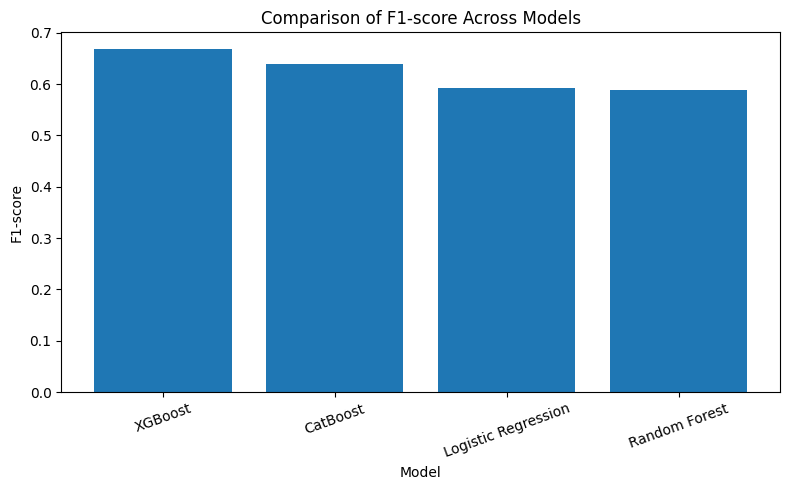

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['F1-score'])
plt.title('Comparison of F1-scores Across Models')
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

19. Select Current Best Model

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print("Temporary best model based on F1-score:", best_model_name)

Model terbaik sementara berdasarkan F1-score: XGBoost


In [ ]:
from scipy.stats import randint, uniform

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [ ]:
# ===== XGBoost Hyperparameter Tuning Based on F1-score (Training Set Only) =====

xgb_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

param_dist = {
    'model__n_estimators': randint(300, 901),
    'model__max_depth': randint(4, 9),
    'model__learning_rate': uniform(0.01, 0.08),
    'model__subsample': uniform(0.7, 0.3),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 6),
    'model__gamma': uniform(0.0, 0.6),
    'model__reg_lambda': [1, 2, 5, 10],
    'model__reg_alpha': [0, 0.1, 0.5, 1.0]
}

cv_tuning = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=cv_tuning,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    refit=True
)

xgb_search.fit(X_train, y_train)

print("Best CV F1-score:", xgb_search.best_score_)
print("Best parameters:", xgb_search.best_params_)

best_xgb_params = {
    k.replace('model__', ''): v
    for k, v in xgb_search.best_params_.items()
}

print("\n===== BEST XGBOOST PARAMETERS =====")
print(best_xgb_params)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV F1-score: 0.6753893024055704
Best params: {'model__colsample_bytree': np.float64(0.7410275425336676), 'model__gamma': np.float64(0.1828687548948174), 'model__learning_rate': np.float64(0.02317246825143534), 'model__max_depth': 6, 'model__min_child_weight': 1, 'model__n_estimators': 617, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': np.float64(0.7359596102001048)}

===== BEST XGBOOST PARAMS =====
{'colsample_bytree': np.float64(0.7410275425336676), 'gamma': np.float64(0.1828687548948174), 'learning_rate': np.float64(0.02317246825143534), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 617, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': np.float64(0.7359596102001048)}


In [ ]:
def make_tuned_xgb(scale_pos_weight_value=None):
    return XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight_value,
        **best_xgb_params
    )

Stage 2 = Ablation Study

1. Additional Imports for Stage 2

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

2. Re-evaluation Function

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Setting': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob)
    }

3. Preprocessor for XGBoost

In [ ]:
numeric_transformer_noscale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_noscale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_noscale = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_noscale, numerical_features),
        ('cat', categorical_transformer_noscale, categorical_features)
    ]
)

4. Calculate scale_pos_weight

In [ ]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 5.463958060288335


5. XGBoost Baseline Model (Ablation Starting Point)

In [ ]:
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

6. Ablation 1 — Baseline XGBoost

In [ ]:
ablation_results = []

pipeline_xgb_base = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('model', xgb_base)
])

pipeline_xgb_base.fit(X_train, y_train)
y_pred_base = pipeline_xgb_base.predict(X_test)
y_prob_base = pipeline_xgb_base.predict_proba(X_test)[:, 1]

ablation_results.append(
    evaluate_model('XGBoost Baseline', y_test, y_pred_base, y_prob_base)
)

print(classification_report(y_test, y_pred_base, zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      2084
           1       0.59      0.77      0.67       382

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.80      2466
weighted avg       0.90      0.88      0.89      2466



7. Ablation 2 — With Balancing (SMOTE) vs Without Balancing

In [ ]:
pipeline_xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])

pipeline_xgb_smote.fit(X_train, y_train)
y_pred_smote = pipeline_xgb_smote.predict(X_test)
y_prob_smote = pipeline_xgb_smote.predict_proba(X_test)[:, 1]

ablation_results.append(
    evaluate_model('XGBoost + SMOTE', y_test, y_pred_smote, y_prob_smote)
)

print(classification_report(y_test, y_pred_smote, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2084
           1       0.71      0.60      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.78      0.80      2466
weighted avg       0.89      0.90      0.90      2466



8. Ablation 3 — Feature Selection (Selecting Best Features After Preprocessing)

In [ ]:
# 8 Ablation 3 — Feature Selection
# Using tuned XGBoost from RandomizedSearchCV

pipeline_xgb_fs = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('model', make_tuned_xgb(scale_pos_weight))
])

pipeline_xgb_fs.fit(X_train, y_train)

y_pred_fs = pipeline_xgb_fs.predict(X_test)
y_prob_fs = pipeline_xgb_fs.predict_proba(X_test)[:, 1]

ablation_results.append(
    evaluate_model(
        'XGBoost + Feature Selection',
        y_test,
        y_pred_fs,
        y_prob_fs
    )
)

print(classification_report(y_test, y_pred_fs, zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      2084
           1       0.59      0.77      0.67       382

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.80      2466
weighted avg       0.90      0.88      0.89      2466



In [ ]:
# 8A Sensitivity Analysis — Tuned XGBoost + Feature Selection on Deduplicated Dataset

# Compute scale_pos_weight based on deduplicated training set
neg_dedup, pos_dedup = np.bincount(y_train_dedup)
scale_pos_weight_dedup = neg_dedup / pos_dedup

print("Deduplicated scale_pos_weight:", scale_pos_weight_dedup)

# Build pipeline identical to main final model
pipeline_xgb_fs_dedup = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('model', make_tuned_xgb(scale_pos_weight_dedup))
])

# Train on deduplicated dataset
pipeline_xgb_fs_dedup.fit(X_train_dedup, y_train_dedup)

# Predict on deduplicated test set
y_pred_fs_dedup = pipeline_xgb_fs_dedup.predict(X_test_dedup)
y_prob_fs_dedup = pipeline_xgb_fs_dedup.predict_proba(X_test_dedup)[:, 1]

# Store sensitivity analysis results
dedup_sensitivity_result = evaluate_model(
    'XGBoost + Feature Selection (Deduplicated)',
    y_test_dedup,
    y_pred_fs_dedup,
    y_prob_fs_dedup
)

dedup_sensitivity_df = pd.DataFrame([dedup_sensitivity_result])

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']:
    dedup_sensitivity_df[col] = dedup_sensitivity_df[col].round(4)

print("===== SENSITIVITY ANALYSIS: DEDUPLICATED DATASET =====")
display(dedup_sensitivity_df)

print("\n===== CLASSIFICATION REPORT: DEDUPLICATED DATASET =====")
print(classification_report(y_test_dedup, y_pred_fs_dedup, zero_division=0))

dedup_output_path = '/content/drive/MyDrive/onlineShope/results_dedup_sensitivity_xgb_fs.csv'
dedup_sensitivity_df.to_csv(dedup_output_path, index=False)
print(f"Dedup sensitivity results saved at: {dedup_output_path}")

scale_pos_weight deduplicated: 5.398427260812582
===== SENSITIVITY ANALYSIS: DATASET DEDUPLICATED =====


,Setting,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,XGBoost + Feature Selection (Deduplicated),0.8779,0.5843,0.7618,0.6614,0.9299,0.7445



===== CLASSIFICATION REPORT: DEDUPLICATED DATASET =====
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      2059
           1       0.58      0.76      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.79      2441
weighted avg       0.90      0.88      0.88      2441

Hasil sensitivity dedup disimpan di: /content/drive/MyDrive/onlineShope/results_dedup_sensitivity_xgb_fs.csv


In [ ]:
# 8B Feature-Selection k-Sensitivity Analysis
# Testing whether k = 20 remains competitive compared to other selected feature sizes

k_values = [10, 15, 20, 25, 30]
k_sensitivity_results = []

for k in k_values:
    print(f"Evaluating k = {k}...")

    pipeline_xgb_k = Pipeline(steps=[
        ('preprocessor', preprocessor_noscale),
        ('feature_selection', SelectKBest(
            score_func=mutual_info_classif,
            k=k
        )),
        ('model', make_tuned_xgb(scale_pos_weight))
    ])

    pipeline_xgb_k.fit(X_train, y_train)

    y_pred_k = pipeline_xgb_k.predict(X_test)
    y_prob_k = pipeline_xgb_k.predict_proba(X_test)[:, 1]

    k_sensitivity_results.append({
        'k': k,
        'Accuracy': accuracy_score(y_test, y_pred_k),
        'Precision': precision_score(y_test, y_pred_k, zero_division=0),
        'Recall': recall_score(y_test, y_pred_k, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_k, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob_k),
        'PR-AUC': average_precision_score(y_test, y_prob_k)
    })

k_sensitivity_df = pd.DataFrame(k_sensitivity_results)

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']:
    k_sensitivity_df[col] = k_sensitivity_df[col].round(4)

print("===== FEATURE-SELECTION k-SENSITIVITY ANALYSIS =====")
display(k_sensitivity_df)

Evaluating k = 10...
Evaluating k = 15...
Evaluating k = 20...
Evaluating k = 25...
Evaluating k = 30...
===== FEATURE-SELECTION k-SENSITIVITY ANALYSIS =====


,k,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,10,0.8739,0.5687,0.7696,0.6541,0.9153,0.7199
1,15,0.8747,0.5712,0.7670,0.6547,0.9170,0.7208
2,20,0.8824,0.5927,0.7696,0.6697,0.9241,0.7272
3,25,0.8796,0.5855,0.7618,0.6621,0.9272,0.7298
4,30,0.8796,0.5848,0.7670,0.6636,0.9278,0.7362


In [ ]:
k_sensitivity_output_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_feature_selection_k_sensitivity_xgb_fs_tuned.csv'
)

k_sensitivity_df.to_csv(
    k_sensitivity_output_path,
    index=False
)

print(f"k-sensitivity results saved at: {k_sensitivity_output_path}")

Hasil k-sensitivity disimpan di: /content/drive/MyDrive/onlineShope/results_feature_selection_k_sensitivity_xgb_fs_tuned.csv


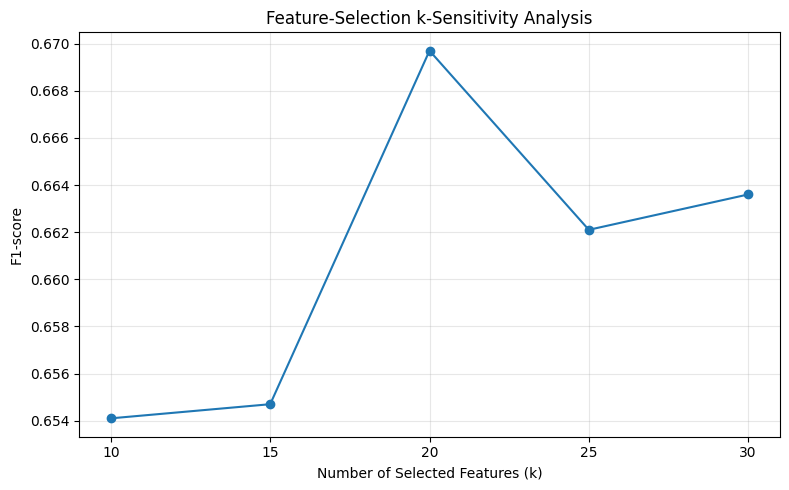

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_sensitivity_df['k'],
    k_sensitivity_df['F1-score'],
    marker='o'
)

plt.title('Feature-Selection k-Sensitivity Analysis')
plt.xlabel('Number of Selected Features (k)')
plt.ylabel('F1-score')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

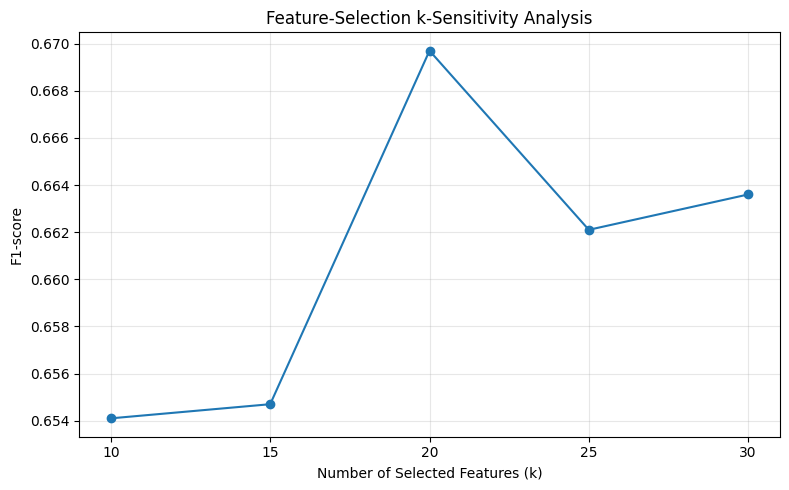

Plot k-sensitivity disimpan di: /content/drive/MyDrive/onlineShope/feature_selection_k_sensitivity_xgb_fs_tuned.png


In [ ]:
k_sensitivity_plot_path = (
    '/content/drive/MyDrive/onlineShope/'
    'feature_selection_k_sensitivity_xgb_fs_tuned.png'
)

plt.figure(figsize=(8, 5))

plt.plot(
    k_sensitivity_df['k'],
    k_sensitivity_df['F1-score'],
    marker='o'
)

plt.title('Feature-Selection k-Sensitivity Analysis')
plt.xlabel('Number of Selected Features (k)')
plt.ylabel('F1-score')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    k_sensitivity_plot_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"k-sensitivity plot saved at: {k_sensitivity_plot_path}")

9. Ablation 4 — Without PageValues

In [ ]:
# 9 Ablation 4 — Without PageValues
# Using the same train-test split as the main experiment

X_train_np = X_train.drop(columns=['PageValues'])
X_test_np = X_test.drop(columns=['PageValues'])

y_train_np = y_train.copy()
y_test_np = y_test.copy()

categorical_features_no_page = categorical_features.copy()
numerical_features_no_page = [
    col for col in numerical_features
    if col != 'PageValues'
]

preprocessor_no_page = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_features_no_page),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features_no_page)
    ]
)

neg_np, pos_np = np.bincount(y_train_np)
scale_pos_weight_np = neg_np / pos_np

pipeline_xgb_no_page = Pipeline(steps=[
    ('preprocessor', preprocessor_no_page),
    ('model', make_tuned_xgb(scale_pos_weight_np))
])

pipeline_xgb_no_page.fit(X_train_np, y_train_np)

y_pred_no_page = pipeline_xgb_no_page.predict(X_test_np)
y_prob_no_page = pipeline_xgb_no_page.predict_proba(X_test_np)[:, 1]

ablation_results.append(
    evaluate_model(
        'XGBoost - PageValues Removed',
        y_test_np,
        y_pred_no_page,
        y_prob_no_page
    )
)

print(classification_report(y_test_np, y_pred_no_page, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      2084
           1       0.30      0.57      0.39       382

    accuracy                           0.73      2466
   macro avg       0.60      0.66      0.61      2466
weighted avg       0.81      0.73      0.76      2466



10. Ablation 5 — Without Temporal Features

In [ ]:
# 10 Ablation 5 — Without temporal features
# Temporal features removed: Month, Weekend, SpecialDay
# Using the same train-test split as the main experiment

temporal_cols = ['Month', 'Weekend', 'SpecialDay']

existing_temporal_cols = [
    col for col in temporal_cols
    if col in X_train.columns
]

X_train_nt = X_train.drop(columns=existing_temporal_cols)
X_test_nt = X_test.drop(columns=existing_temporal_cols)

y_train_nt = y_train.copy()
y_test_nt = y_test.copy()

categorical_features_no_temp = [
    col for col in categorical_features
    if col not in ['Month', 'Weekend']
]

numerical_features_no_temp = [
    col for col in numerical_features
    if col != 'SpecialDay'
]

preprocessor_no_temp = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_features_no_temp),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features_no_temp)
    ]
)

neg_nt, pos_nt = np.bincount(y_train_nt)
scale_pos_weight_nt = neg_nt / pos_nt

pipeline_xgb_no_temp = Pipeline(steps=[
    ('preprocessor', preprocessor_no_temp),
    ('model', make_tuned_xgb(scale_pos_weight_nt))
])

pipeline_xgb_no_temp.fit(X_train_nt, y_train_nt)

y_pred_no_temp = pipeline_xgb_no_temp.predict(X_test_nt)
y_prob_no_temp = pipeline_xgb_no_temp.predict_proba(X_test_nt)[:, 1]

ablation_results.append(
    evaluate_model(
        'XGBoost - Temporal Features Removed',
        y_test_nt,
        y_pred_no_temp,
        y_prob_no_temp
    )
)

print(classification_report(y_test_nt, y_pred_no_temp, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92      2084
           1       0.58      0.73      0.64       382

    accuracy                           0.87      2466
   macro avg       0.76      0.82      0.78      2466
weighted avg       0.89      0.87      0.88      2466



11. Ablation Results Table

In [ ]:
ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']:
    ablation_df[col] = ablation_df[col].round(4)

print("===== XGBOOST ABLATION RESULTS =====")
ablation_df

===== HASIL ABLASI XGBOOST =====


,Setting,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,XGBoost + Feature Selection,0.8824,0.5927,0.7696,0.6697,0.9241,0.7272
1,XGBoost Baseline,0.8808,0.5876,0.7723,0.6674,0.9283,0.7349
2,XGBoost + SMOTE,0.8994,0.7068,0.5995,0.6487,0.9306,0.7432
3,XGBoost - Temporal Features,0.8747,0.5753,0.7304,0.6436,0.8964,0.7026
4,XGBoost - PageValues,0.7295,0.3013,0.5654,0.3931,0.7628,0.3580


12. Save Ablation Results

In [ ]:
ablation_output_path = '/content/drive/MyDrive/onlineShope/results_ablation_xgboost.csv'
ablation_df.to_csv(ablation_output_path, index=False)

print(f"Ablation results saved at: {ablation_output_path}")

Hasil ablasi disimpan di: /content/drive/MyDrive/onlineShope/results_ablation_xgboost.csv


13. Ablation Study — F1-score Comparison Plot

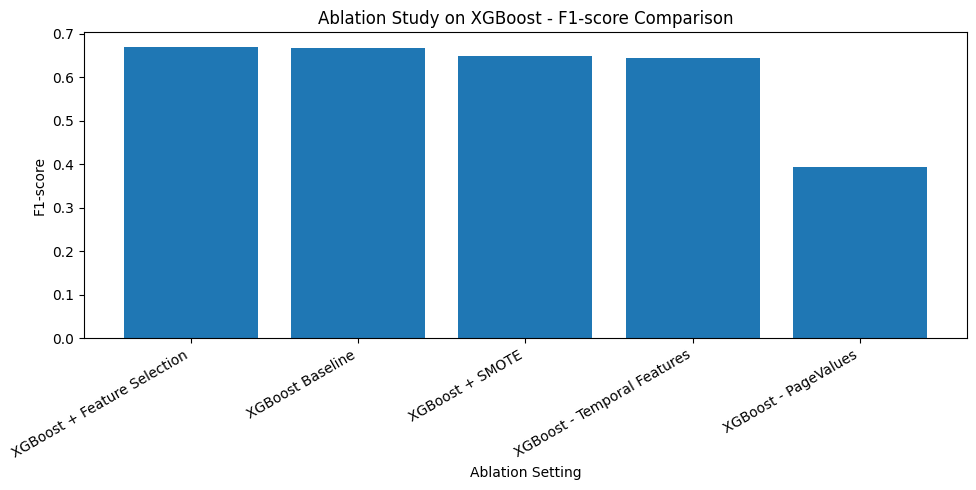

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(ablation_df['Setting'], ablation_df['F1-score'])
plt.title('Ablation Study on XGBoost - F1-score Comparison')
plt.xlabel('Ablation Setting')
plt.ylabel('F1-score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Stage 2 Additional CatBoost

1. CatBoost Ablation Results

In [ ]:
cat_ablation_results = []

2. CatBoost Baseline

In [ ]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

catboost_base = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

catboost_base.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

y_pred_cb_base = catboost_base.predict(X_test_cb)
y_prob_cb_base = catboost_base.predict_proba(X_test_cb)[:, 1]

cat_ablation_results.append(
    evaluate_model('CatBoost Baseline', y_test, y_pred_cb_base, y_prob_cb_base)
)

print(classification_report(y_test, y_pred_cb_base, zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2084
           1       0.53      0.81      0.64       382

    accuracy                           0.86      2466
   macro avg       0.74      0.84      0.78      2466
weighted avg       0.89      0.86      0.87      2466



3. CatBoost Without PageValues

In [ ]:
# 3 CatBoost without PageValues
# Using the same train-test split as the main experiment

X_train_np = X_train.drop(columns=['PageValues'])
X_test_np = X_test.drop(columns=['PageValues'])

y_train_np = y_train.copy()
y_test_np = y_test.copy()

categorical_features_no_page = categorical_features.copy()

X_train_np_cb = X_train_np.copy()
X_test_np_cb = X_test_np.copy()

for col in categorical_features_no_page:
    X_train_np_cb[col] = X_train_np_cb[col].astype(str)
    X_test_np_cb[col] = X_test_np_cb[col].astype(str)

catboost_no_page = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

catboost_no_page.fit(
    X_train_np_cb,
    y_train_np,
    cat_features=categorical_features_no_page
)

y_pred_cb_no_page = catboost_no_page.predict(X_test_np_cb)
y_prob_cb_no_page = catboost_no_page.predict_proba(X_test_np_cb)[:, 1]

cat_ablation_results.append(
    evaluate_model(
        'CatBoost - PageValues Removed',
        y_test_np,
        y_pred_cb_no_page,
        y_prob_cb_no_page
    )
)

print(classification_report(y_test_np, y_pred_cb_no_page, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.68      0.78      2084
           1       0.29      0.72      0.41       382

    accuracy                           0.68      2466
   macro avg       0.61      0.70      0.60      2466
weighted avg       0.83      0.68      0.73      2466



4. CatBoost without Temporal Features

In [ ]:
# 4 CatBoost without temporal features
# Temporal features removed: Month, Weekend, SpecialDay
# Using the same train-test split as the main experiment

temporal_cols = ['Month', 'Weekend', 'SpecialDay']

existing_temporal_cols = [
    col for col in temporal_cols
    if col in X_train.columns
]

X_train_nt = X_train.drop(columns=existing_temporal_cols)
X_test_nt = X_test.drop(columns=existing_temporal_cols)

y_train_nt = y_train.copy()
y_test_nt = y_test.copy()

categorical_features_no_temp = [
    col for col in categorical_features
    if col not in ['Month', 'Weekend']
]

X_train_nt_cb = X_train_nt.copy()
X_test_nt_cb = X_test_nt.copy()

for col in categorical_features_no_temp:
    X_train_nt_cb[col] = X_train_nt_cb[col].astype(str)
    X_test_nt_cb[col] = X_test_nt_cb[col].astype(str)

catboost_no_temp = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

catboost_no_temp.fit(
    X_train_nt_cb,
    y_train_nt,
    cat_features=categorical_features_no_temp
)

y_pred_cb_no_temp = catboost_no_temp.predict(X_test_nt_cb)
y_prob_cb_no_temp = catboost_no_temp.predict_proba(X_test_nt_cb)[:, 1]

cat_ablation_results.append(
    evaluate_model(
        'CatBoost - Temporal Features Removed',
        y_test_nt,
        y_pred_cb_no_temp,
        y_prob_cb_no_temp
    )
)

print(classification_report(y_test_nt, y_pred_cb_no_temp, zero_division=0))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2084
           1       0.54      0.80      0.65       382

    accuracy                           0.86      2466
   macro avg       0.75      0.84      0.78      2466
weighted avg       0.89      0.86      0.87      2466



5. CatBoost Ablation Results

In [ ]:
cat_ablation_df = pd.DataFrame(cat_ablation_results)
cat_ablation_df = cat_ablation_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']:
    cat_ablation_df[col] = cat_ablation_df[col].round(4)

print("===== CATBOOST ABLATION RESULTS =====")
cat_ablation_df

===== HASIL ABLASI CATBOOST =====


,Setting,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,CatBoost - Temporal Features,0.8646,0.5427,0.7984,0.6462,0.8994,0.7098
1,CatBoost Baseline,0.8585,0.5282,0.8089,0.6391,0.9299,0.7405
2,CatBoost - PageValues,0.6837,0.2905,0.7225,0.4144,0.7725,0.3542


6. Save CatBoost Ablation Results

In [ ]:
cat_ablation_output_path = '/content/drive/MyDrive/onlineShope/results_ablation_catboost.csv'
cat_ablation_df.to_csv(cat_ablation_output_path, index=False)

print(f"CatBoost ablation results saved at: {cat_ablation_output_path}")

Hasil ablasi CatBoost disimpan di: /content/drive/MyDrive/onlineShope/results_ablation_catboost.csv


7. Ablation Study — F1-score Comparison Plot

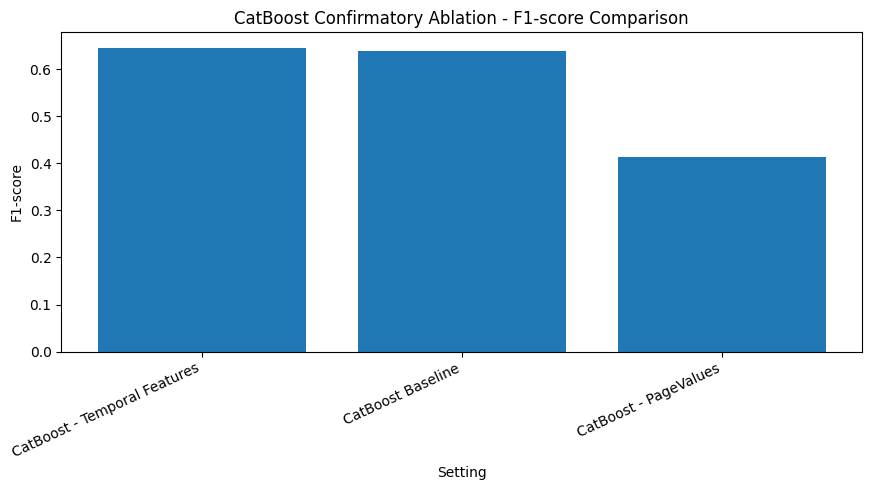

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(cat_ablation_df['Setting'], cat_ablation_df['F1-score'])
plt.title('CatBoost Confirmatory Ablation - F1-score Comparison')
plt.xlabel('Setting')
plt.ylabel('F1-score')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

Stage 3 SHAP Model Final

In [ ]:
import shap

1. Refit Final XGBoost Model + Feature Selection

We rebuild the same final pipeline as in Stage 2.

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline

# Stage 3 — Refit final tuned XGBoost + Feature Selection model
pipeline_xgb_final = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('feature_selection', SelectKBest(
        score_func=mutual_info_classif,
        k=20
    )),
    ('model', make_tuned_xgb(scale_pos_weight))
])

pipeline_xgb_final.fit(X_train, y_train)
pipeline_xgb_final

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues',
                                                   'SpecialDay']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=np.float64(0.02317246825143534),
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=617,
                               n_jobs=None, num_parallel_tree=None, ...))])

3. Extract Preprocessed Data

Since SHAP for XGBoost requires the final numerical input, we extract the data after preprocessing + feature selection.

In [ ]:
X_train_processed = pipeline_xgb_final.named_steps['preprocessor'].transform(X_train)
X_test_processed = pipeline_xgb_final.named_steps['preprocessor'].transform(X_test)

selector = pipeline_xgb_final.named_steps['feature_selection']
X_train_selected = selector.transform(X_train_processed)
X_test_selected = selector.transform(X_test_processed)

xgb_final_model = pipeline_xgb_final.named_steps['model']

4. Extract feature names after preprocessing

This is important so that the SHAP plot has proper feature names.

In [ ]:
feature_names_after_preprocessing = pipeline_xgb_final.named_steps['preprocessor'].get_feature_names_out()
selected_feature_mask = selector.get_support()
selected_feature_names = feature_names_after_preprocessing[selected_feature_mask]

print("Number of selected features:", len(selected_feature_names))
print(selected_feature_names)

Jumlah fitur terpilih: 20
['num__Administrative' 'num__Administrative_Duration' 'num__Informational'
 'num__Informational_Duration' 'num__ProductRelated'
 'num__ProductRelated_Duration' 'num__BounceRates' 'num__ExitRates'
 'num__PageValues' 'num__SpecialDay' 'cat__Month_May' 'cat__Month_Nov'
 'cat__OperatingSystems_2' 'cat__OperatingSystems_3' 'cat__TrafficType_1'
 'cat__TrafficType_2' 'cat__TrafficType_3' 'cat__TrafficType_13'
 'cat__VisitorType_New_Visitor' 'cat__VisitorType_Returning_Visitor']


5. Convert to DataFrame so feature names are clearly readable

In [ ]:
from scipy import sparse

# 5 Convert to DataFrame so feature names are clearly readable
# Handles both dense and sparse outputs after OneHotEncoder + SelectKBest

if sparse.issparse(X_train_selected):
    X_train_selected_df = pd.DataFrame.sparse.from_spmatrix(
        X_train_selected,
        columns=selected_feature_names
    )
else:
    X_train_selected_df = pd.DataFrame(
        X_train_selected,
        columns=selected_feature_names
    )

if sparse.issparse(X_test_selected):
    X_test_selected_df = pd.DataFrame.sparse.from_spmatrix(
        X_test_selected,
        columns=selected_feature_names
    )
else:
    X_test_selected_df = pd.DataFrame(
        X_test_selected,
        columns=selected_feature_names
    )

print("Train selected shape:", X_train_selected_df.shape)
print("Test selected shape :", X_test_selected_df.shape)

Shape train selected: (9864, 20)
Shape test selected : (2466, 20)


6. Take a sample for SHAP

To reduce computational load, we use a subset of the test data.

In [ ]:
sample_size = min(500, len(X_test_selected_df))
X_shap_sample = X_test_selected_df.sample(n=sample_size, random_state=42)

print("SHAP sample size:", X_shap_sample.shape)

Ukuran sampel SHAP: (500, 20)


7. Run SHAP Explainer

In [ ]:
explainer = shap.TreeExplainer(xgb_final_model)
shap_values = explainer.shap_values(X_shap_sample)

8. SHAP Summary Plot

This is the main and most important plot.

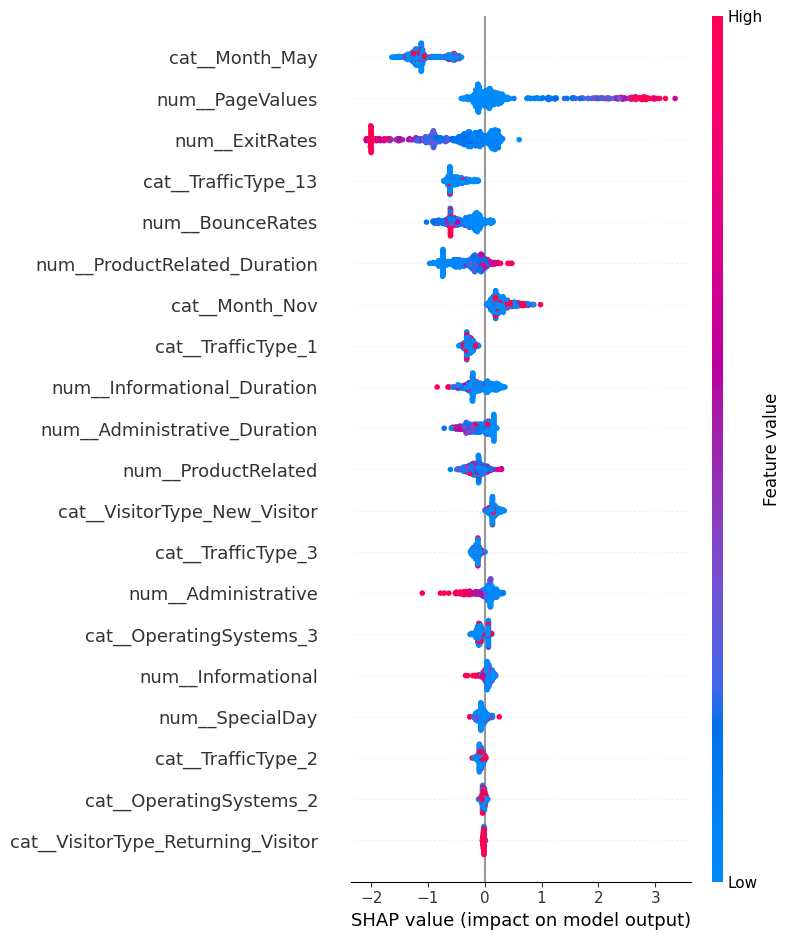

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.show()

9. SHAP Feature Importance Bar Plot

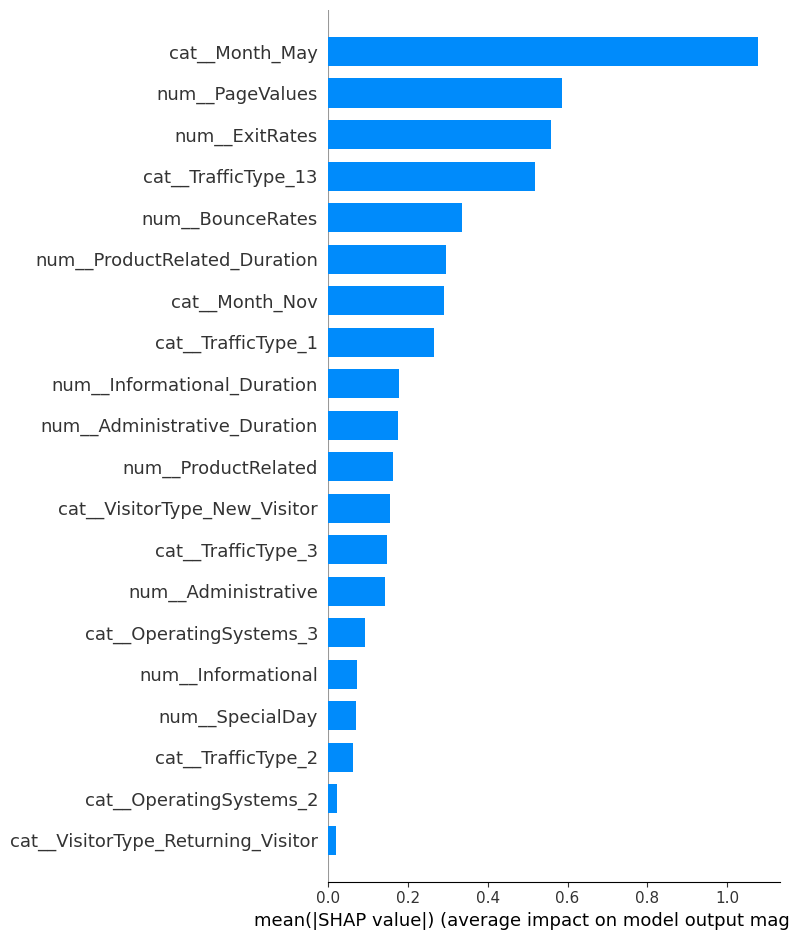

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

10. Mean Absolute SHAP Table

In [ ]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': X_shap_sample.columns,
    'MeanAbsSHAP': mean_abs_shap
}).sort_values(by='MeanAbsSHAP', ascending=False).reset_index(drop=True)

shap_importance_df.head(15)

,Feature,MeanAbsSHAP
0,cat__Month_May,1.077605
1,num__PageValues,0.585673
2,num__ExitRates,0.559304
3,cat__TrafficType_13,0.518361
4,num__BounceRates,0.337047
5,num__ProductRelated_Duration,0.295703
6,cat__Month_Nov,0.290608
7,cat__TrafficType_1,0.264798
8,num__Informational_Duration,0.179354
9,num__Administrative_Duration,0.175485


11. Save SHAP Importance Table

In [ ]:
shap_output_path = '/content/drive/MyDrive/onlineShope/results_shap_importance_xgb_fs.csv'
shap_importance_df.to_csv(shap_output_path, index=False)

print(f"SHAP importance results saved at: {shap_output_path}")

Hasil SHAP importance disimpan di: /content/drive/MyDrive/onlineShope/results_shap_importance_xgb_fs.csv


12. Save plot SHAP

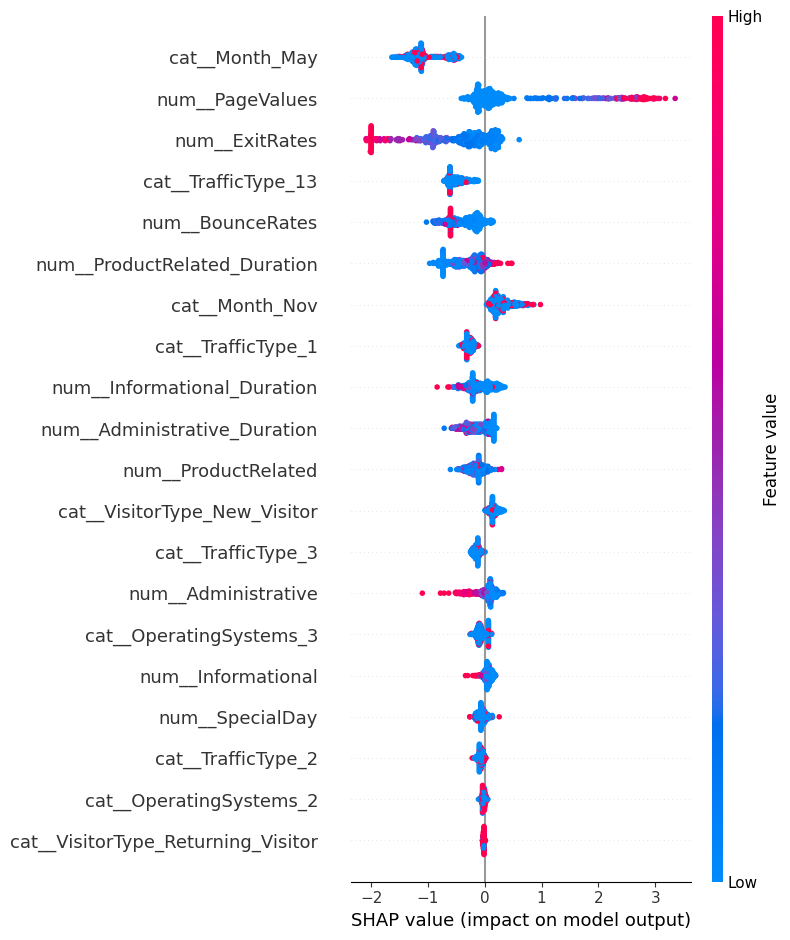

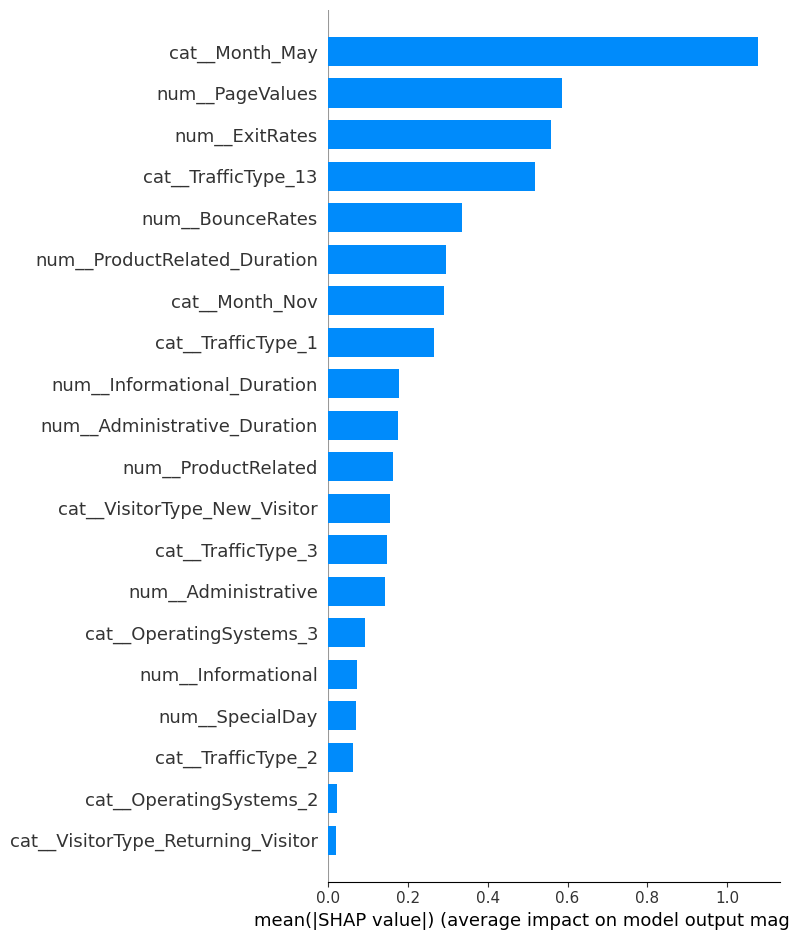

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/onlineShope/shap_summary_xgb_fs.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/onlineShope/shap_bar_xgb_fs.png', dpi=300, bbox_inches='tight')
plt.show()

Jenis kasus lokal: True Positive
Posisi observasi pada test set: 2
Label aktual: 1
Probabilitas prediksi Revenue=1: 0.9829
Prediksi kelas: 1


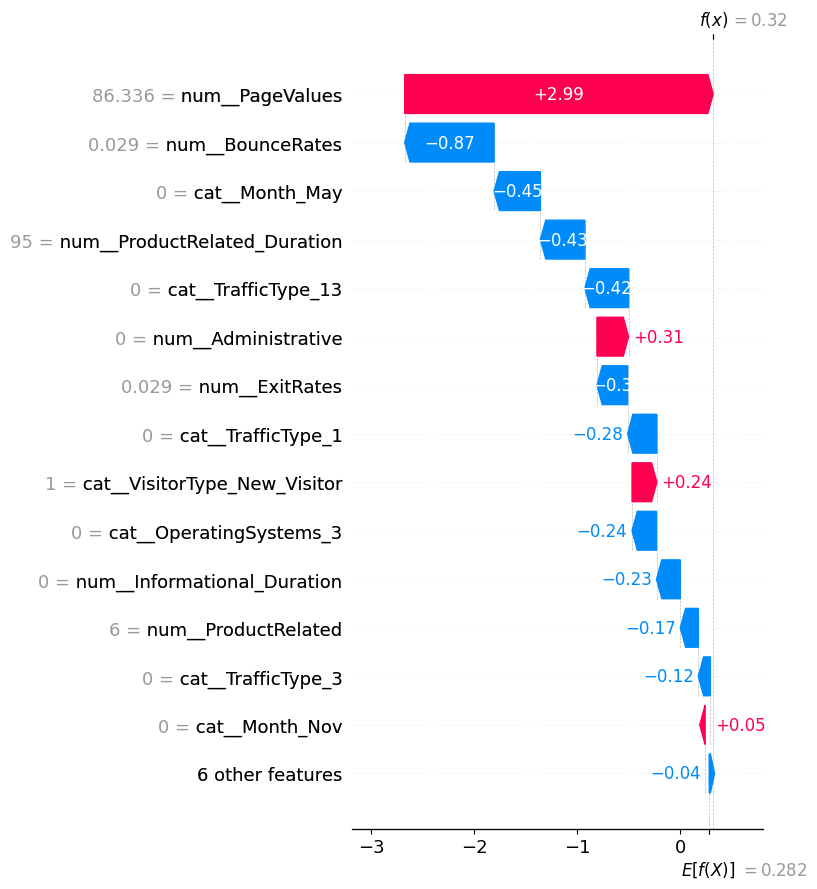

In [ ]:
# 13 Local SHAP Explanation — example of individual prediction explanation

# Final prediction on main test set
y_prob_test_final = pipeline_xgb_final.predict_proba(X_test)[:, 1]
y_pred_test_final = (y_prob_test_final >= 0.50).astype(int)

# Select one true positive if available
true_positive_positions = np.where(
    (y_test.to_numpy() == 1) &
    (y_pred_test_final == 1)
)[0]

if len(true_positive_positions) > 0:
    local_position = true_positive_positions[0]
    local_case_type = "True Positive"
else:
    # Fallback: take observation with highest predicted probability
    local_position = int(np.argmax(y_prob_test_final))
    local_case_type = "Highest Predicted Probability"

print("Local case type:", local_case_type)
print("Test set observation index:", local_position)
print("Actual label:", int(y_test.iloc[local_position]))
print("Predicted probability Revenue=1:", round(float(y_prob_test_final[local_position]), 4))
print("Predicted class:", int(y_pred_test_final[local_position]))

# Take single instance in final feature representation
X_local_instance = X_test_selected_df.iloc[[local_position]]

# Compute local SHAP
local_explanation = explainer(X_local_instance)

# Waterfall plot
shap.plots.waterfall(
    local_explanation[0],
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/onlineShope/shap_local_waterfall_xgb_fs_tuned.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# 14 Local SHAP Contribution Table

local_shap_df = pd.DataFrame({
    'Feature': X_local_instance.columns,
    'FeatureValue': X_local_instance.iloc[0].values,
    'SHAPValue': local_explanation.values[0]
})

local_shap_df['AbsSHAPValue'] = local_shap_df['SHAPValue'].abs()

local_shap_df = local_shap_df.sort_values(
    by='AbsSHAPValue',
    ascending=False
).reset_index(drop=True)

print("===== TOP LOCAL SHAP CONTRIBUTIONS =====")
display(local_shap_df.head(15))

local_shap_output_path = '/content/drive/MyDrive/onlineShope/results_shap_local_xgb_fs_tuned.csv'
local_shap_df.to_csv(local_shap_output_path, index=False)

print(f"Local SHAP table saved at: {local_shap_output_path}")

===== TOP LOCAL SHAP CONTRIBUTIONS =====


,Feature,FeatureValue,SHAPValue,AbsSHAPValue
0,num__PageValues,86.336233,2.993970,2.993970
1,num__BounceRates,0.028571,-0.867730,0.867730
2,cat__Month_May,0,-0.449706,0.449706
3,num__ProductRelated_Duration,95.0,-0.431637,0.431637
4,cat__TrafficType_13,0,-0.423858,0.423858
5,num__Administrative,0,0.306892,0.306892
6,num__ExitRates,0.028571,-0.297396,0.297396
7,cat__TrafficType_1,0,-0.283910,0.283910
8,cat__VisitorType_New_Visitor,1.0,0.240869,0.240869
9,cat__OperatingSystems_3,0,-0.237501,0.237501


Tabel local SHAP disimpan di: /content/drive/MyDrive/onlineShope/results_shap_local_xgb_fs_tuned.csv


Stage 4 — Nested Cross-Validation

In [ ]:
# ============================================================
# STAGE 4 — NESTED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_dist_nested = {
    'model__n_estimators': randint(300, 901),
    'model__max_depth': randint(4, 9),
    'model__learning_rate': uniform(0.01, 0.08),
    'model__subsample': uniform(0.7, 0.3),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 6),
    'model__gamma': uniform(0.0, 0.6),
    'model__reg_lambda': [1, 2, 5, 10],
    'model__reg_alpha': [0, 0.1, 0.5, 1.0]
}

nested_cv_results = []
nested_best_params = []

for fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer_cv.split(X, y),
    start=1
):
    print(f"\n===== OUTER FOLD {fold} =====")

    X_outer_train = X.iloc[outer_train_idx]
    X_outer_test = X.iloc[outer_test_idx]

    y_outer_train = y.iloc[outer_train_idx]
    y_outer_test = y.iloc[outer_test_idx]

    # Compute scale_pos_weight only from outer training fold
    neg_outer, pos_outer = np.bincount(y_outer_train)
    scale_pos_weight_outer = neg_outer / pos_outer

    nested_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_noscale),
        ('feature_selection', SelectKBest(
            score_func=mutual_info_classif,
            k=20
        )),
        ('model', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            scale_pos_weight=scale_pos_weight_outer
        ))
    ])

    nested_search = RandomizedSearchCV(
        estimator=nested_pipeline,
        param_distributions=param_dist_nested,
        n_iter=30,
        scoring='f1',
        cv=inner_cv,
        verbose=0,
        n_jobs=-1,
        random_state=42,
        refit=True
    )

    nested_search.fit(X_outer_train, y_outer_train)

    best_nested_model = nested_search.best_estimator_

    y_outer_pred = best_nested_model.predict(X_outer_test)
    y_outer_prob = best_nested_model.predict_proba(X_outer_test)[:, 1]

    fold_result = {
        'Fold': fold,
        'Inner Best CV F1-score': nested_search.best_score_,
        'Accuracy': accuracy_score(y_outer_test, y_outer_pred),
        'Precision': precision_score(y_outer_test, y_outer_pred, zero_division=0),
        'Recall': recall_score(y_outer_test, y_outer_pred, zero_division=0),
        'F1-score': f1_score(y_outer_test, y_outer_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_outer_test, y_outer_prob),
        'PR-AUC': average_precision_score(y_outer_test, y_outer_prob)
    }

    nested_cv_results.append(fold_result)

    nested_best_params.append({
        'Fold': fold,
        **nested_search.best_params_
    })

    print("Best inner CV F1-score:", round(nested_search.best_score_, 4))
    print("Outer fold F1-score:", round(fold_result['F1-score'], 4))


===== OUTER FOLD 1 =====
Best inner CV F1-score: 0.6629
Outer fold F1-score: 0.6737

===== OUTER FOLD 2 =====
Best inner CV F1-score: 0.672
Outer fold F1-score: 0.6627

===== OUTER FOLD 3 =====
Best inner CV F1-score: 0.6703
Outer fold F1-score: 0.6667

===== OUTER FOLD 4 =====
Best inner CV F1-score: 0.6699
Outer fold F1-score: 0.6637

===== OUTER FOLD 5 =====
Best inner CV F1-score: 0.6702
Outer fold F1-score: 0.6645


In [ ]:
nested_cv_results_df = pd.DataFrame(nested_cv_results)

for col in [
    'Inner Best CV F1-score',
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score',
    'ROC-AUC',
    'PR-AUC'
]:
    nested_cv_results_df[col] = nested_cv_results_df[col].round(4)

print("===== NESTED CROSS-VALIDATION RESULTS PER FOLD =====")
display(nested_cv_results_df)

===== HASIL NESTED CROSS-VALIDATION PER FOLD =====


,Fold,Inner Best CV F1-score,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,1,0.6629,0.8877,0.6111,0.7507,0.6737,0.9356,0.7417
1,2,0.6720,0.8844,0.6034,0.7349,0.6627,0.9225,0.7151
2,3,0.6703,0.8747,0.5670,0.8089,0.6667,0.9318,0.7475
3,4,0.6699,0.8755,0.5706,0.7932,0.6637,0.9272,0.7501
4,5,0.6702,0.8759,0.5717,0.7932,0.6645,0.9302,0.7360


In [ ]:
nested_cv_summary_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC',
        'PR-AUC'
    ],
    'Mean': [
        nested_cv_results_df['Accuracy'].mean(),
        nested_cv_results_df['Precision'].mean(),
        nested_cv_results_df['Recall'].mean(),
        nested_cv_results_df['F1-score'].mean(),
        nested_cv_results_df['ROC-AUC'].mean(),
        nested_cv_results_df['PR-AUC'].mean()
    ],
    'Std': [
        nested_cv_results_df['Accuracy'].std(),
        nested_cv_results_df['Precision'].std(),
        nested_cv_results_df['Recall'].std(),
        nested_cv_results_df['F1-score'].std(),
        nested_cv_results_df['ROC-AUC'].std(),
        nested_cv_results_df['PR-AUC'].std()
    ]
})

nested_cv_summary_df[['Mean', 'Std']] = nested_cv_summary_df[['Mean', 'Std']].round(4)

print("===== NESTED CROSS-VALIDATION SUMMARY =====")
display(nested_cv_summary_df)

===== RINGKASAN NESTED CROSS-VALIDATION =====


,Metric,Mean,Std
0,Accuracy,0.8796,0.0060
1,Precision,0.5848,0.0208
2,Recall,0.7762,0.0316
3,F1-score,0.6663,0.0044
4,ROC-AUC,0.9295,0.0049
5,PR-AUC,0.7381,0.0140


In [ ]:
nested_cv_results_path = '/content/drive/MyDrive/onlineShope/results_nested_cv_folds_xgb_fs_tuned.csv'
nested_cv_summary_path = '/content/drive/MyDrive/onlineShope/results_nested_cv_summary_xgb_fs_tuned.csv'
nested_cv_params_path = '/content/drive/MyDrive/onlineShope/results_nested_cv_best_params_xgb_fs_tuned.csv'

nested_cv_results_df.to_csv(nested_cv_results_path, index=False)
nested_cv_summary_df.to_csv(nested_cv_summary_path, index=False)
pd.DataFrame(nested_best_params).to_csv(nested_cv_params_path, index=False)

print(f"Nested CV fold results saved at: {nested_cv_results_path}")
print(f"Nested CV summary saved at: {nested_cv_summary_path}")
print(f"Best parameters per fold saved at: {nested_cv_params_path}")

Hasil nested CV per fold disimpan di: /content/drive/MyDrive/onlineShope/results_nested_cv_folds_xgb_fs_tuned.csv
Ringkasan nested CV disimpan di: /content/drive/MyDrive/onlineShope/results_nested_cv_summary_xgb_fs_tuned.csv
Best params per fold disimpan di: /content/drive/MyDrive/onlineShope/results_nested_cv_best_params_xgb_fs_tuned.csv


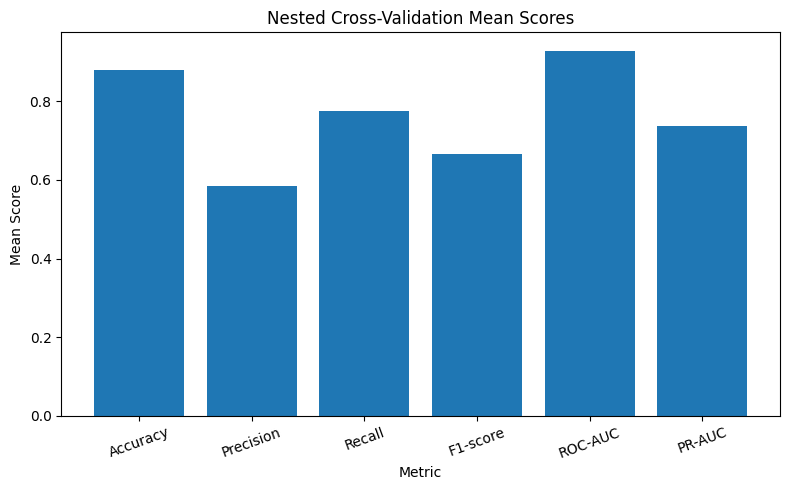

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    nested_cv_summary_df['Metric'],
    nested_cv_summary_df['Mean']
)
plt.title('Nested Cross-Validation Mean Scores')
plt.xlabel('Metric')
plt.ylabel('Mean Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Stage 5 — Threshold Tuning

===== TRAIN-VALIDATION SPLIT UNTUK THRESHOLD TUNING =====
Train_sub shape: (7891, 17)
Validation shape: (1973, 17)

Distribusi y_train_sub:
Revenue
0    84.526676
1    15.473324
Name: proportion, dtype: float64

Distribusi y_val:
Revenue
0    84.541308
1    15.458692
Name: proportion, dtype: float64

scale_pos_weight train_sub: 5.462735462735463

===== HASIL THRESHOLD TUNING PADA VALIDATION SET =====


,Threshold,Accuracy,Precision,Recall,F1-score
0,0.70,0.9067,0.7037,0.6852,0.6944
1,0.60,0.8986,0.6540,0.7311,0.6904
2,0.65,0.9027,0.6805,0.6984,0.6893
3,0.75,0.9037,0.7061,0.6459,0.6747
4,0.55,0.8855,0.6048,0.7475,0.6686
5,0.50,0.8799,0.5846,0.7705,0.6648
6,0.80,0.9057,0.7409,0.6000,0.6630
7,0.45,0.8702,0.5566,0.7902,0.6531
8,0.40,0.8616,0.5343,0.8164,0.6459
9,0.35,0.8490,0.5070,0.8262,0.6284



===== THRESHOLD TERBAIK BERDASARKAN VALIDATION F1-SCORE =====
Best threshold: 0.7


,0
Threshold,0.7000
Accuracy,0.9067
Precision,0.7037
Recall,0.6852
F1-score,0.6944



===== THRESHOLD DEFAULT 0.50 PADA VALIDATION SET =====


,Threshold,Accuracy,Precision,Recall,F1-score
5,0.5,0.8799,0.5846,0.7705,0.6648



===== PERBANDINGAN FINAL PADA UNTOUCHED TEST SET =====


,Setting,Accuracy,Precision,Recall,F1-score
0,Default Threshold (0.50),0.8824,0.5927,0.7696,0.6697
1,Validation-Selected Threshold (0.70),0.8958,0.6676,0.6518,0.6596


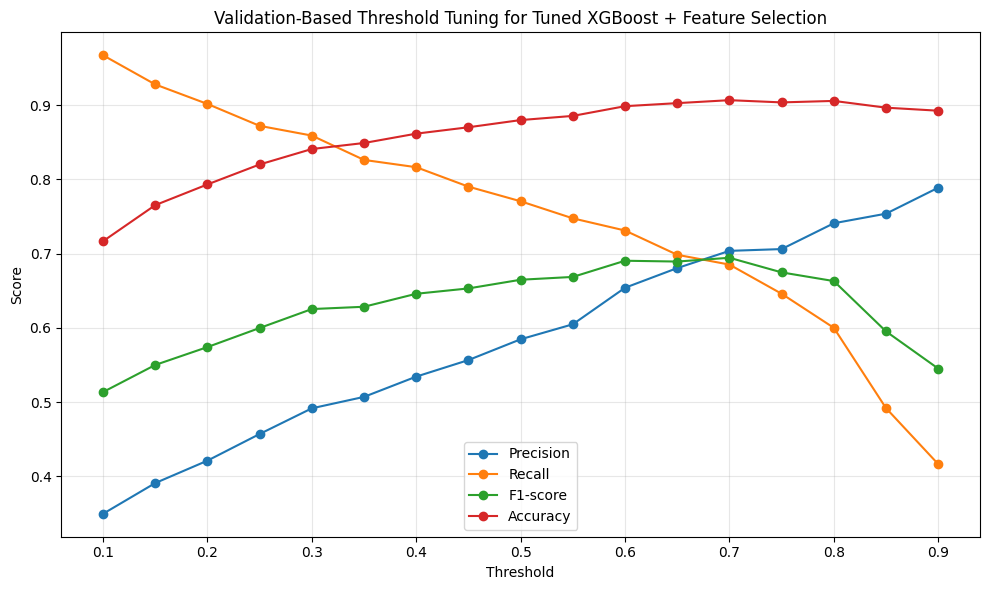


===== CONFUSION MATRIX: TEST SET, VALIDATION-SELECTED THRESHOLD =====
[[1960  124]
 [ 133  249]]

===== CLASSIFICATION REPORT: TEST SET, VALIDATION-SELECTED THRESHOLD =====
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2084
           1       0.67      0.65      0.66       382

    accuracy                           0.90      2466
   macro avg       0.80      0.80      0.80      2466
weighted avg       0.89      0.90      0.90      2466


===== FILE HASIL DISIMPAN =====
Validation threshold tuning:
/content/drive/MyDrive/onlineShope/results_threshold_tuning_validation_xgb_fs_tuned.csv

Final untouched test-set comparison:
/content/drive/MyDrive/onlineShope/results_threshold_test_comparison_xgb_fs_tuned.csv


In [ ]:
# ============================================================
# STAGE 5 — VALIDATION-BASED THRESHOLD TUNING
# Final model = Tuned XGBoost + Feature Selection
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from IPython.display import display

# ------------------------------------------------------------
# 1. Split training set into train_sub and validation set
# ------------------------------------------------------------
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("===== TRAIN-VALIDATION SPLIT FOR THRESHOLD TUNING =====")
print("Train_sub shape:", X_train_sub.shape)
print("Validation shape:", X_val.shape)

print("\nDistribution of y_train_sub:")
print(y_train_sub.value_counts(normalize=True) * 100)

print("\nDistribution of y_val:")
print(y_val.value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 2. Compute scale_pos_weight only from train_sub
# ------------------------------------------------------------
neg_sub, pos_sub = np.bincount(y_train_sub)
scale_pos_weight_sub = neg_sub / pos_sub

print("\nscale_pos_weight train_sub:", scale_pos_weight_sub)


# ------------------------------------------------------------
# 3. Train model on train_sub
# ------------------------------------------------------------
pipeline_xgb_val = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('feature_selection', SelectKBest(
        score_func=mutual_info_classif,
        k=20
    )),
    ('model', make_tuned_xgb(scale_pos_weight_sub))
])

pipeline_xgb_val.fit(X_train_sub, y_train_sub)


# ------------------------------------------------------------
# 4. Find best threshold on validation set
# ------------------------------------------------------------
y_prob_val = pipeline_xgb_val.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for thr in thresholds:
    y_pred_val_thr = (y_prob_val >= thr).astype(int)

    threshold_results.append({
        'Threshold': round(float(thr), 2),
        'Accuracy': accuracy_score(y_val, y_pred_val_thr),
        'Precision': precision_score(y_val, y_pred_val_thr, zero_division=0),
        'Recall': recall_score(y_val, y_pred_val_thr, zero_division=0),
        'F1-score': f1_score(y_val, y_pred_val_thr, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values(
    by='F1-score',
    ascending=False
).reset_index(drop=True)

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    threshold_df[col] = threshold_df[col].round(4)

print("\n===== THRESHOLD TUNING RESULTS ON VALIDATION SET =====")
display(threshold_df)


# ------------------------------------------------------------
# 5. Best threshold based on validation F1-score
# ------------------------------------------------------------
best_threshold_row = threshold_df.iloc[0]
best_threshold = float(best_threshold_row['Threshold'])

print("\n===== BEST THRESHOLD BASED ON VALIDATION F1-SCORE =====")
print("Best threshold:", best_threshold)
display(best_threshold_row)

default_threshold_row = threshold_df[
    threshold_df['Threshold'] == 0.50
]

print("\n===== DEFAULT THRESHOLD 0.50 ON VALIDATION SET =====")
display(default_threshold_row)


# ------------------------------------------------------------
# 6. Refit final model on full training set
# ------------------------------------------------------------
neg_full, pos_full = np.bincount(y_train)
scale_pos_weight_full = neg_full / pos_full

pipeline_xgb_final_threshold = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('feature_selection', SelectKBest(
        score_func=mutual_info_classif,
        k=20
    )),
    ('model', make_tuned_xgb(scale_pos_weight_full))
])

pipeline_xgb_final_threshold.fit(X_train, y_train)


# ------------------------------------------------------------
# 7. Final evaluation on untouched test set
# ------------------------------------------------------------
y_prob_test = pipeline_xgb_final_threshold.predict_proba(X_test)[:, 1]

y_pred_test_default = (y_prob_test >= 0.50).astype(int)
y_pred_test_selected = (y_prob_test >= best_threshold).astype(int)

test_comparison_df = pd.DataFrame([
    {
        'Setting': 'Default Threshold (0.50)',
        'Accuracy': accuracy_score(y_test, y_pred_test_default),
        'Precision': precision_score(y_test, y_pred_test_default, zero_division=0),
        'Recall': recall_score(y_test, y_pred_test_default, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_test_default, zero_division=0)
    },
    {
        'Setting': f'Validation-Selected Threshold ({best_threshold:.2f})',
        'Accuracy': accuracy_score(y_test, y_pred_test_selected),
        'Precision': precision_score(y_test, y_pred_test_selected, zero_division=0),
        'Recall': recall_score(y_test, y_pred_test_selected, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_test_selected, zero_division=0)
    }
])

for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    test_comparison_df[col] = test_comparison_df[col].round(4)

print("\n===== FINAL TEST SET COMPARISON =====")
display(test_comparison_df)


# ------------------------------------------------------------
# 8. Threshold tuning plot
# ------------------------------------------------------------
threshold_plot_df = threshold_df.sort_values(
    by='Threshold'
).reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.plot(threshold_plot_df['Threshold'], threshold_plot_df['Precision'], marker='o', label='Precision')
plt.plot(threshold_plot_df['Threshold'], threshold_plot_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_plot_df['Threshold'], threshold_plot_df['F1-score'], marker='o', label='F1-score')
plt.plot(threshold_plot_df['Threshold'], threshold_plot_df['Accuracy'], marker='o', label='Accuracy')

plt.title('Validation-Based Threshold Tuning for Tuned XGBoost + Feature Selection')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Confusion matrix & classification report
# ------------------------------------------------------------
cm_selected_thr = confusion_matrix(
    y_test,
    y_pred_test_selected
)

print("\n===== CONFUSION MATRIX: TEST SET (SELECTED THRESHOLD) =====")
print(cm_selected_thr)

print("\n===== CLASSIFICATION REPORT: TEST SET (SELECTED THRESHOLD) =====")
print(
    classification_report(
        y_test,
        y_pred_test_selected,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 10. Save outputs
# ------------------------------------------------------------
threshold_validation_output_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_threshold_tuning_validation_xgb_fs_tuned.csv'
)

threshold_test_comparison_output_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_threshold_test_comparison_xgb_fs_tuned.csv'
)

threshold_df.to_csv(
    threshold_validation_output_path,
    index=False
)

test_comparison_df.to_csv(
    threshold_test_comparison_output_path,
    index=False
)

print("\n===== FILES SAVED =====")
print("Validation threshold tuning:")
print(threshold_validation_output_path)

print("\nFinal test-set comparison:")
print(threshold_test_comparison_output_path)

Stage 6

===== CALIBRATION ASSESSMENT =====
Jumlah sampel test: 2466
Jumlah probabilitas prediksi: 2466

===== CALIBRATION SUMMARY =====


,Model,Evaluation Set,Brier Score
0,Tuned XGBoost + Feature Selection,Untouched Test Set,0.087061



===== CALIBRATION CURVE VALUES =====


,Mean Predicted Probability,Observed Positive Fraction
0,0.001933,0.000000
1,0.005303,0.000000
2,0.011649,0.000000
3,0.027749,0.008097
4,0.052214,0.044715
5,0.091534,0.040486
6,0.171336,0.097561
7,0.350708,0.165992
8,0.690086,0.439024
9,0.929251,0.753036


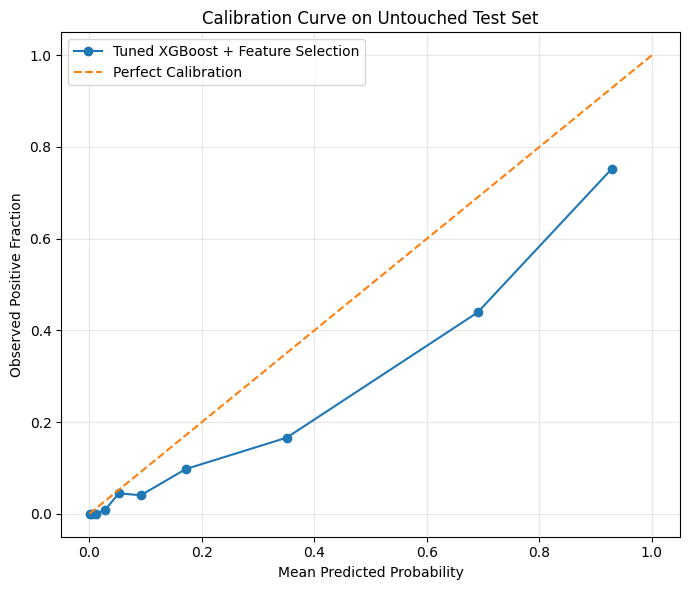

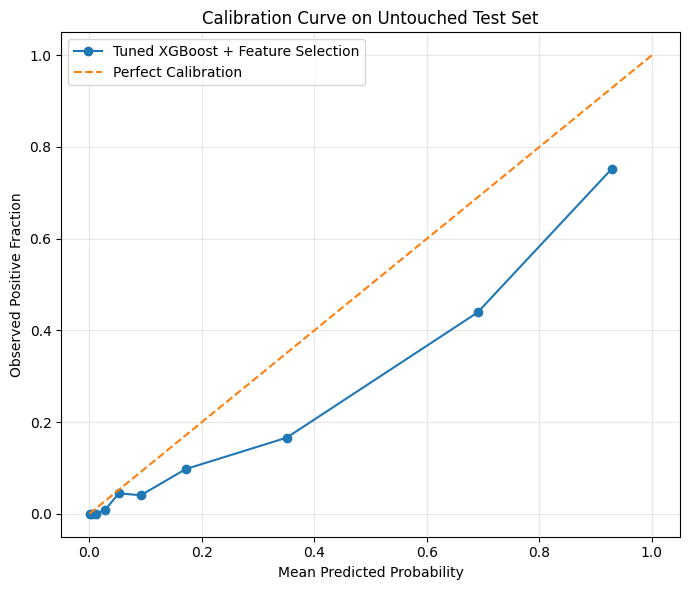


===== FILE CALIBRATION DISIMPAN =====
/content/drive/MyDrive/onlineShope/results_calibration_summary_xgb_fs_tuned.csv
/content/drive/MyDrive/onlineShope/results_calibration_curve_xgb_fs_tuned.csv
/content/drive/MyDrive/onlineShope/calibration_curve_xgb_fs_tuned.png


In [ ]:
# ============================================================
# STAGE 6 — CALIBRATION ASSESSMENT
# Final model = Tuned XGBoost + Feature Selection
# Probabilities evaluated on untouched test set
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ------------------------------------------------------------
# 1. Ensure test probabilities from Stage 5
# ------------------------------------------------------------
# This variable should already exist from Stage 5:
# y_prob_test

print("===== CALIBRATION ASSESSMENT =====")
print("Number of test samples:", len(y_test))
print("Number of predicted probabilities:", len(y_prob_test))


# ------------------------------------------------------------
# 2. Compute Brier Score
# ------------------------------------------------------------
brier_score = brier_score_loss(y_test, y_prob_test)

calibration_summary_df = pd.DataFrame([
    {
        'Model': 'Tuned XGBoost + Feature Selection',
        'Evaluation Set': 'Untouched Test Set',
        'Brier Score': round(brier_score, 6)
    }
])

print("\n===== CALIBRATION SUMMARY =====")
display(calibration_summary_df)


# ------------------------------------------------------------
# 3. Calibration curve
# ------------------------------------------------------------
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_test,
    n_bins=10,
    strategy='quantile'
)

calibration_curve_df = pd.DataFrame({
    'Mean Predicted Probability': prob_pred,
    'Observed Positive Fraction': prob_true
}).round(6)

print("\n===== CALIBRATION CURVE VALUES =====")
display(calibration_curve_df)


# ------------------------------------------------------------
# 4. Reliability diagram
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Tuned XGBoost + Feature Selection'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.title('Calibration Curve on Untouched Test Set')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Positive Fraction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Save outputs
# ------------------------------------------------------------
calibration_summary_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_calibration_summary_xgb_fs_tuned.csv'
)

calibration_curve_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_calibration_curve_xgb_fs_tuned.csv'
)

calibration_plot_path = (
    '/content/drive/MyDrive/onlineShope/'
    'calibration_curve_xgb_fs_tuned.png'
)

calibration_summary_df.to_csv(calibration_summary_path, index=False)
calibration_curve_df.to_csv(calibration_curve_path, index=False)

# Save plot again (clean separation)
plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Tuned XGBoost + Feature Selection'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.title('Calibration Curve on Untouched Test Set')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Positive Fraction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    calibration_plot_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\n===== CALIBRATION FILES SAVED =====")
print(calibration_summary_path)
print(calibration_curve_path)
print(calibration_plot_path)

Stage 7

In [ ]:
# ============================================================
# STAGE 7 — BOOTSTRAP 95% CONFIDENCE INTERVAL
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# ------------------------------------------------------------
# 1. Function to compute main metrics
# ------------------------------------------------------------
def calculate_metrics_with_threshold(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'Brier Score': brier_score_loss(y_true, y_prob)
    }


# ------------------------------------------------------------
# 2. Bootstrap CI function
# ------------------------------------------------------------
def bootstrap_confidence_intervals(
    y_true,
    y_prob,
    threshold=0.50,
    n_bootstrap=2000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true_array = np.asarray(y_true)
    y_prob_array = np.asarray(y_prob)

    n_samples = len(y_true_array)

    bootstrap_records = []
    valid_iterations = 0

    while valid_iterations < n_bootstrap:
        sample_indices = rng.integers(
            low=0,
            high=n_samples,
            size=n_samples
        )

        y_true_boot = y_true_array[sample_indices]
        y_prob_boot = y_prob_array[sample_indices]

        # ROC-AUC and PR-AUC require both classes to be present
        if len(np.unique(y_true_boot)) < 2:
            continue

        boot_metrics = calculate_metrics_with_threshold(
            y_true_boot,
            y_prob_boot,
            threshold=threshold
        )

        bootstrap_records.append(boot_metrics)
        valid_iterations += 1

    bootstrap_df = pd.DataFrame(bootstrap_records)

    point_estimates = calculate_metrics_with_threshold(
        y_true_array,
        y_prob_array,
        threshold=threshold
    )

    summary_rows = []

    for metric in bootstrap_df.columns:
        lower_ci = bootstrap_df[metric].quantile(0.025)
        upper_ci = bootstrap_df[metric].quantile(0.975)

        summary_rows.append({
            'Metric': metric,
            'Point Estimate': point_estimates[metric],
            '95% CI Lower': lower_ci,
            '95% CI Upper': upper_ci
        })

    summary_df = pd.DataFrame(summary_rows)

    for col in ['Point Estimate', '95% CI Lower', '95% CI Upper']:
        summary_df[col] = summary_df[col].round(4)

    return summary_df, bootstrap_df

In [ ]:
# ------------------------------------------------------------
# 3. Bootstrap CI for final model at default threshold 0.50
# ------------------------------------------------------------
bootstrap_default_summary_df, bootstrap_default_all_df = bootstrap_confidence_intervals(
    y_true=y_test,
    y_prob=y_prob_test,
    threshold=0.50,
    n_bootstrap=2000,
    random_state=42
)

bootstrap_default_summary_df.insert(
    0,
    'Setting',
    'Default Threshold (0.50)'
)

print("===== BOOTSTRAP 95% CI: DEFAULT THRESHOLD 0.50 =====")
display(bootstrap_default_summary_df)

===== BOOTSTRAP 95% CI: DEFAULT THRESHOLD 0.50 =====


,Setting,Metric,Point Estimate,95% CI Lower,95% CI Upper
0,Default Threshold (0.50),Accuracy,0.8824,0.8690,0.8946
1,Default Threshold (0.50),Precision,0.5927,0.5487,0.6335
2,Default Threshold (0.50),Recall,0.7696,0.7297,0.8110
3,Default Threshold (0.50),F1-score,0.6697,0.6345,0.7042
4,Default Threshold (0.50),ROC-AUC,0.9241,0.9103,0.9363
5,Default Threshold (0.50),PR-AUC,0.7272,0.6817,0.7687
6,Default Threshold (0.50),Brier Score,0.0871,0.0795,0.0955


In [ ]:
# ------------------------------------------------------------
# 4. Bootstrap CI for validation-selected threshold
# ------------------------------------------------------------
bootstrap_selected_summary_df, bootstrap_selected_all_df = bootstrap_confidence_intervals(
    y_true=y_test,
    y_prob=y_prob_test,
    threshold=best_threshold,
    n_bootstrap=2000,
    random_state=42
)

bootstrap_selected_summary_df.insert(
    0,
    'Setting',
    f'Validation-Selected Threshold ({best_threshold:.2f})'
)

print("===== BOOTSTRAP 95% CI: VALIDATION-SELECTED THRESHOLD =====")
display(bootstrap_selected_summary_df)

In [ ]:
# ------------------------------------------------------------
# 5. Combine bootstrap CI summaries
# ------------------------------------------------------------
bootstrap_ci_summary_df = pd.concat(
    [
        bootstrap_default_summary_df,
        bootstrap_selected_summary_df
    ],
    ignore_index=True
)

print("===== BOOTSTRAP 95% CONFIDENCE INTERVAL SUMMARY =====")
display(bootstrap_ci_summary_df)

In [ ]:
# ------------------------------------------------------------
# 6. Save bootstrap results
# ------------------------------------------------------------
bootstrap_ci_summary_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_bootstrap_ci_summary_xgb_fs_tuned.csv'
)

bootstrap_default_all_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_bootstrap_all_default_threshold_xgb_fs_tuned.csv'
)

bootstrap_selected_all_path = (
    '/content/drive/MyDrive/onlineShope/'
    'results_bootstrap_all_selected_threshold_xgb_fs_tuned.csv'
)

bootstrap_ci_summary_df.to_csv(
    bootstrap_ci_summary_path,
    index=False
)

bootstrap_default_all_df.to_csv(
    bootstrap_default_all_path,
    index=False
)

bootstrap_selected_all_df.to_csv(
    bootstrap_selected_all_path,
    index=False
)

print("===== BOOTSTRAP FILES SAVED =====")
print(bootstrap_ci_summary_path)
print(bootstrap_default_all_path)
print(bootstrap_selected_all_path)

In [ ]:
# ------------------------------------------------------------
# 7. Plot confidence intervals for main metrics
#    Focus on default threshold 0.50
# ------------------------------------------------------------
plot_bootstrap_df = bootstrap_default_summary_df[
    bootstrap_default_summary_df['Metric'].isin([
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC',
        'PR-AUC'
    ])
].copy()

plot_bootstrap_df['Lower Error'] = (
    plot_bootstrap_df['Point Estimate'] -
    plot_bootstrap_df['95% CI Lower']
)

plot_bootstrap_df['Upper Error'] = (
    plot_bootstrap_df['95% CI Upper'] -
    plot_bootstrap_df['Point Estimate']
)

plt.figure(figsize=(9, 6))

plt.errorbar(
    x=plot_bootstrap_df['Metric'],
    y=plot_bootstrap_df['Point Estimate'],
    yerr=[
        plot_bootstrap_df['Lower Error'],
        plot_bootstrap_df['Upper Error']
    ],
    fmt='o',
    capsize=5
)

plt.title('Bootstrap 95% Confidence Intervals for Main Test Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

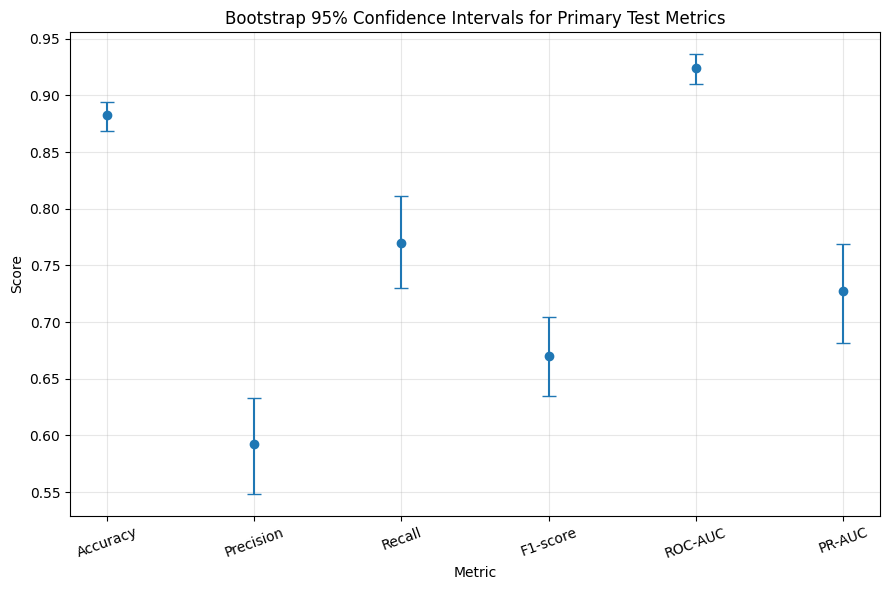

Plot bootstrap CI disimpan di:
/content/drive/MyDrive/onlineShope/bootstrap_ci_primary_metrics_xgb_fs_tuned.png


In [ ]:
bootstrap_ci_plot_path = (
    '/content/drive/MyDrive/onlineShope/'
    'bootstrap_ci_primary_metrics_xgb_fs_tuned.png'
)

plt.figure(figsize=(9, 6))

plt.errorbar(
    x=plot_bootstrap_df['Metric'],
    y=plot_bootstrap_df['Point Estimate'],
    yerr=[
        plot_bootstrap_df['Lower Error'],
        plot_bootstrap_df['Upper Error']
    ],
    fmt='o',
    capsize=5
)

plt.title('Bootstrap 95% Confidence Intervals for Primary Test Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    bootstrap_ci_plot_path,
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("Bootstrap CI plot saved at:")
print(bootstrap_ci_plot_path)